# Phase 2: AML Typology Classification Model
**Purpose:** Given a transaction already flagged as AML by Phase 1, predict WHICH typology it belongs to.

**Input:** Phase 1 outputs (model, features, train/test splits, metadata)
**Output:** Probability distribution across 10 AML typologies per transaction

**Pipeline:**
1. Load Phase 1 artifacts
2. Prepare AML-only dataset with typology labels
3. Add typology-discriminating interaction features
4. Feature selection (remove features useless for typology separation)
5. Hyperparameter tuning with rare-class boosting
6. Evaluation with per-typology accuracy
7. Build production output tables
8. Save Phase 2 model and outputs


## 1 — Environment Setup


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from collections import defaultdict, Counter

print("Libraries loaded")


Libraries loaded


## 2 — Load Phase 1 Artifacts
Load the model, features, train/test data, and metadata saved by the Phase 1 notebook.


In [2]:
# ═══ Configure paths ═══
# Update this to match your Phase 1 output directory
PHASE1_DIR = os.path.join(os.path.dirname(os.getcwd()), "python_scripts", "ml_outputs")
OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "python_scripts", "phase2_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Phase 1 directory: {PHASE1_DIR}")
print(f"Phase 2 output:    {OUTPUT_DIR}")

# Check Phase 1 files exist
required_files = ["final_lgb_model.txt", "model_metadata.json",
                  "X_train.parquet", "X_test.parquet",
                  "y_train.parquet", "y_test.parquet"]

print(f"\nPhase 1 artifacts:")
for f in required_files:
    path = os.path.join(PHASE1_DIR, f)
    exists = os.path.exists(path)
    size = os.path.getsize(path) / (1024*1024) if exists else 0
    status = f"{size:.2f} MB" if exists else "⚠ MISSING"
    print(f"  {f:<35s} {status}")
    if not exists:
        raise FileNotFoundError(f"Missing Phase 1 artifact: {path}")

print(f"\n✓ All Phase 1 artifacts found")


Phase 1 directory: c:\Users\VISHNUPRIYA\OneDrive\Desktop\Freelancing\AIGEN\smartsentry_aml_model\python_scripts\ml_outputs
Phase 2 output:    c:\Users\VISHNUPRIYA\OneDrive\Desktop\Freelancing\AIGEN\smartsentry_aml_model\python_scripts\phase2_outputs

Phase 1 artifacts:
  final_lgb_model.txt                 13.10 MB
  model_metadata.json                 0.01 MB
  X_train.parquet                     49.53 MB
  X_test.parquet                      14.09 MB
  y_train.parquet                     0.05 MB
  y_test.parquet                      0.01 MB

✓ All Phase 1 artifacts found


## 3 — Load Phase 1 Data & Model


In [3]:
print("Loading Phase 1 artifacts...")

# Load model
final_model = lgb.Booster(model_file=os.path.join(PHASE1_DIR, "final_lgb_model.txt"))
print(f"  Phase 1 model loaded ({final_model.num_trees()} trees)")

# Load metadata
with open(os.path.join(PHASE1_DIR, "model_metadata.json")) as f:
    metadata = json.load(f)

features_final = metadata["features"]
best_thresh = metadata["optimal_threshold"]
best_strategy = metadata["best_strategy"]
print(f"  Features: {len(features_final)}")
print(f"  Threshold: {best_thresh}")
print(f"  Strategy: {best_strategy}")

# Load train/test splits
X_train = pd.read_parquet(os.path.join(PHASE1_DIR, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(PHASE1_DIR, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(PHASE1_DIR, "y_train.parquet")).iloc[:, 0]
y_test = pd.read_parquet(os.path.join(PHASE1_DIR, "y_test.parquet")).iloc[:, 0]

print(f"  Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"  AML in train: {(y_train==1).sum():,} | AML in test: {(y_test==1).sum():,}")

# Load the full feature-engineered dataset for typology labels
PHASE1_DIR = os.path.join(os.path.dirname(os.getcwd()), "python_scripts", "ml_outputs")

FEATURES_FILE = os.path.join(os.path.dirname(PHASE1_DIR), "df_ml_phase_1.parquet")
if not os.path.exists(FEATURES_FILE):
    # Try alternative paths
    for alt in ["df_ml_phase_1.parquet", "df_ml_phase_1.parquet"]:
        alt_path = os.path.join(os.path.dirname(PHASE1_DIR), alt)
        if os.path.exists(alt_path):
            FEATURES_FILE = alt_path
            break
#FEATURES_FILE = 
df_ml = pd.read_parquet(r'C:\Users\VISHNUPRIYA\OneDrive\Desktop\Freelancing\AIGEN\smartsentry_aml_model\python_scripts\ml_outputs\df_ml_phase_1.parquet')
print(f"  Full dataset: {len(df_ml):,} rows × {len(df_ml.columns)} columns")
print(f"  is_aml=1: {(df_ml['is_aml']==1).sum():,}")

# Verify indices align
train_indices = X_train.index
test_indices = X_test.index
print(f"\n✓ Phase 1 data loaded successfully")


Loading Phase 1 artifacts...
  Phase 1 model loaded (1000 trees)
  Features: 232
  Threshold: 0.5
  Strategy: SMOTE+1.5xWt
  Train: 310,876 | Test: 77,719
  AML in train: 62,992 | AML in test: 15,748
  Full dataset: 388,595 rows × 359 columns
  is_aml=1: 78,740

✓ Phase 1 data loaded successfully


## 4 — Generate Phase 1 Scores


In [4]:
print("Scoring full dataset with Phase 1 model...")

X_full = df_ml[features_final].copy()
for c in X_full.columns:
    X_full[c] = pd.to_numeric(X_full[c], errors="coerce").fillna(0)

df_ml["_phase1_score"] = final_model.predict(X_full)
phase2_features = features_final + ["_phase1_score"]

print(f"  Phase 1 scores computed: range [{df_ml['_phase1_score'].min():.4f}, {df_ml['_phase1_score'].max():.4f}]")
print(f"  Phase 2 feature count: {len(phase2_features)} (Phase 1 features + phase1_score)")


Scoring full dataset with Phase 1 model...
  Phase 1 scores computed: range [0.0000, 0.9999]
  Phase 2 feature count: 233 (Phase 1 features + phase1_score)


## 5 — Prepare AML-Only Dataset
Filter to AML transactions and assign typology labels. Each transaction has exactly one typology.


In [5]:
print("=" * 90)
print("PHASE 2: TYPOLOGY CLASSIFICATION")
print("=" * 90)

# ── Step 1: Prepare typology labels ──
print("\n── Step 1: Prepare Typology Labels ──")
typ_col = "aml_typology"

aml_labeled = df_ml[(df_ml["is_aml"] == 1)].copy()

# Clean typology labels
aml_labeled["_clean_typ"] = aml_labeled[typ_col].astype(str).apply(
    lambda x: x.strip() if x and x not in ("nan", "", "None") else ""
)
aml_labeled = aml_labeled[aml_labeled["_clean_typ"] != ""]

# Verify single typology per transaction
multi_check = aml_labeled["_clean_typ"].str.contains(";", na=False).sum()
print(f"  Multi-typology transactions: {multi_check} (should be 0)")

if multi_check > 0:
    print("  WARNING: Multi-typology found — using rarest-first assignment")
    typ_global = Counter()
    for t in aml_labeled["_clean_typ"]:
        for p in str(t).split("; "):
            if p.strip(): typ_global[p.strip()] += 1
    aml_labeled["_clean_typ"] = aml_labeled["_clean_typ"].apply(
        lambda x: min([p.strip() for p in x.split("; ") if p.strip()],
                      key=lambda p: typ_global.get(p, 999999)) if ";" in str(x) else x
    )

typology_classes = sorted(aml_labeled["_clean_typ"].unique())
typ_to_idx = {t: i for i, t in enumerate(typology_classes)}
idx_to_typ = {i: t for t, i in typ_to_idx.items()}
aml_labeled["_typ_label"] = aml_labeled["_clean_typ"].map(typ_to_idx)
n_classes = len(typology_classes)

print(f"\n  AML transactions with labels: {len(aml_labeled):,}")
print(f"  Typology classes: {n_classes}")
print(f"\n  {'Idx':<4s} {'Typology':<45s} {'Count':>8s} {'%':>7s}")
print(f"  {'─'*68}")
for t, i in typ_to_idx.items():
    cnt = (aml_labeled["_typ_label"] == i).sum()
    print(f"  {i:<4d} {t:<45s} {cnt:>8,} {cnt/len(aml_labeled)*100:>6.1f}%")


PHASE 2: TYPOLOGY CLASSIFICATION

── Step 1: Prepare Typology Labels ──
  Multi-typology transactions: 0 (should be 0)

  AML transactions with labels: 78,740
  Typology classes: 10

  Idx  Typology                                         Count       %
  ────────────────────────────────────────────────────────────────────
  0    Charity Abuse                                    4,520    5.7%
  1    Circular Transaction Loop                        4,879    6.2%
  2    Funnel Account Network                          21,068   26.8%
  3    High-Risk Corridor Transfer                      6,618    8.4%
  4    Money Mule Network                               5,257    6.7%
  5    Pass-Through Transit Hub                         4,453    5.7%
  6    Rapid Multi-Hop Layering                        14,649   18.6%
  7    Structuring (Smurfing)                           6,536    8.3%
  8    Third-Party Payment Web                          7,990   10.1%
  9    Underground Banking (Hawala)           

## 6 — Stratified Train/Test Split


In [6]:
print("\n── Step 2: Stratified Split ──")

X_aml = aml_labeled[phase2_features].copy()
for c in X_aml.columns:
    X_aml[c] = pd.to_numeric(X_aml[c], errors="coerce").fillna(0)
y_aml = aml_labeled["_typ_label"].astype(int)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_aml, y_aml, test_size=0.20, random_state=42, stratify=y_aml
)

total_p2 = len(y_train_2)

# Base class weights (inverse frequency + median boost)
class_weights_p2 = {}
median_count = np.median([(y_train_2 == i).sum() for i in range(n_classes)])
for i in range(n_classes):
    cnt = max((y_train_2 == i).sum(), 1)
    base_weight = total_p2 / (n_classes * cnt)
    boost = min(2.5, median_count / cnt) if cnt < median_count else 1.0
    class_weights_p2[i] = base_weight * boost

sample_weights_p2 = np.array([class_weights_p2[y] for y in y_train_2])

print(f"  Train: {len(X_train_2):,} | Test: {len(X_test_2):,}")
print("  " + "-" * 70)
print("  Typology                                       Train    Test  Weight")
print("  " + "-" * 70)
for i, t in idx_to_typ.items():
    cnt = (y_train_2 == i).sum()
    boost_flag = " BOOSTED" if cnt < median_count else ""
    print(f"  {t:<45s} {(y_train_2==i).sum():>7,} {(y_test_2==i).sum():>7,} {class_weights_p2[i]:>7.4f}{boost_flag}")

# =====================================================================
# CV-BASED WEAK CLASS DETECTION
# Uses ONLY train set via out-of-fold predictions.
# Test set is never touched here — no leakage.
# =====================================================================
print("\n── CV: Detecting Weak Classes (train-only OOF) ──")
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score as _recall_score

cv_probe = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(y_train_2), dtype=int)

# Lightweight probe — just enough to detect weak classes reliably
probe_params = {
    "objective": "multiclass", "num_class": n_classes, "metric": "multi_logloss",
    "num_leaves": 63, "max_depth": 8, "min_child_samples": 10,
    "learning_rate": 0.05, "reg_alpha": 0.1, "reg_lambda": 0.5,
    "subsample": 0.8, "colsample_bytree": 0.8, "verbosity": -1,
    "random_state": 42, "n_jobs": -1, "is_unbalance": True
}

for fold, (tr_idx, val_idx) in enumerate(cv_probe.split(X_train_2, y_train_2)):
    print(f"  Fold {fold+1}/5...", end=" ", flush=True)
    X_tr  = X_train_2.iloc[tr_idx];  X_val = X_train_2.iloc[val_idx]
    y_tr  = y_train_2.iloc[tr_idx];  y_val = y_train_2.iloc[val_idx]
    w_tr  = sample_weights_p2[tr_idx]

    ds_cv  = lgb.Dataset(X_tr,  label=y_tr,  weight=w_tr)
    val_cv = lgb.Dataset(X_val, label=y_val, reference=ds_cv)

    mdl_cv = lgb.train(probe_params, ds_cv, num_boost_round=300,
                       valid_sets=[val_cv],
                       callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])
    oof_preds[val_idx] = mdl_cv.predict(X_val).argmax(axis=1)
    print("done")

# Recall computed on OOF predictions — test set is NEVER used here
oof_recall  = _recall_score(y_train_2, oof_preds, average=None)
mean_recall = oof_recall.mean()

print(f"\n  Mean OOF Recall: {mean_recall:.4f}")
print("  " + "-" * 65)
print("  Typology                                       OOF Recall   Boost")
print("  " + "-" * 65)
for i in range(n_classes):
    recall = oof_recall[i]
    if recall < mean_recall:
        # Boost inversely proportional to weakness, capped at 3x
        boost = min(3.0, mean_recall / (recall + 1e-6))
        class_weights_p2[i] *= boost
        flag = " BOOSTED"
    else:
        boost = 1.0
        flag  = ""
    print(f"  {idx_to_typ[i]:<45s} {recall:>10.4f} {boost:>7.4f}{flag}")

# Recompute sample weights with dynamically adjusted class weights
sample_weights_p2 = np.array([class_weights_p2[y] for y in y_train_2])
print("\n  Sample weights updated based on OOF recall (test set untouched)")



── Step 2: Stratified Split ──
  Train: 62,992 | Test: 15,748
  ----------------------------------------------------------------------
  Typology                                       Train    Test  Weight
  ----------------------------------------------------------------------
  Charity Abuse                                   3,616     904  2.2727 BOOSTED
  Circular Transaction Loop                       3,903     976  1.9507 BOOSTED
  Funnel Account Network                         16,855   4,213  0.3737
  High-Risk Corridor Transfer                     5,294   1,324  1.1899
  Money Mule Network                              4,206   1,051  1.6798 BOOSTED
  Pass-Through Transit Hub                        3,562     891  2.3421 BOOSTED
  Rapid Multi-Hop Layering                       11,719   2,930  0.5375
  Structuring (Smurfing)                          5,229   1,307  1.2047
  Third-Party Payment Web                         6,392   1,598  0.9855
  Underground Banking (Hawala)          

## 7 — Typology-Discriminating Interaction Features
Features specifically designed to separate typologies from each other.


In [7]:
print("\n── Step 2a: Phase 2 Interaction Features ──")
interaction_count = 0

# 1. Cash × amount — separates Structuring (cash 8K-10K)
if "cash_flag_enc" in X_train_2.columns and "transaction_amount" in X_train_2.columns:
    X_train_2["_p2_cash_x_amt"] = X_train_2["cash_flag_enc"] * X_train_2["transaction_amount"]
    X_test_2["_p2_cash_x_amt"] = X_test_2["cash_flag_enc"] * X_test_2["transaction_amount"]
    phase2_features.append("_p2_cash_x_amt")
    interaction_count += 1

# 2. Cross-border × amount — separates Corridor and Hawala
if "ip_flag_cross_border" in X_train_2.columns:
    X_train_2["_p2_xborder_amt"] = X_train_2["ip_flag_cross_border"] * X_train_2["transaction_amount"]
    X_test_2["_p2_xborder_amt"] = X_test_2["ip_flag_cross_border"] * X_test_2["transaction_amount"]
    phase2_features.append("_p2_xborder_amt")
    interaction_count += 1

# 3. Rule count — typologies have different rule trigger patterns
rule_cols_p2 = [c for c in X_train_2.columns if c.startswith("rule_") and c not in {"rule_score"}]
if rule_cols_p2:
    X_train_2["_p2_rule_count"] = X_train_2[rule_cols_p2].sum(axis=1)
    X_test_2["_p2_rule_count"] = X_test_2[rule_cols_p2].sum(axis=1)
    phase2_features.append("_p2_rule_count")
    interaction_count += 1

# 4. Counterparties × amount — Funnel/Mule (many) vs Corridor (few)
cp_col = next((c for c in X_train_2.columns if "unique_counterparties" in c), None)
if cp_col:
    X_train_2["_p2_cp_x_amt"] = X_train_2[cp_col] * np.log1p(X_train_2["transaction_amount"])
    X_test_2["_p2_cp_x_amt"] = X_test_2[cp_col] * np.log1p(X_test_2["transaction_amount"])
    phase2_features.append("_p2_cp_x_amt")
    interaction_count += 1

# 5. Velocity × balance drain — Pass-Through (instant forward)
if "sender_pct_balance_moved" in X_train_2.columns and "sender_acct_txn_count_24h" in X_train_2.columns:
    X_train_2["_p2_drain_speed"] = X_train_2["sender_pct_balance_moved"] * X_train_2["sender_acct_txn_count_24h"]
    X_test_2["_p2_drain_speed"] = X_test_2["sender_pct_balance_moved"] * X_test_2["sender_acct_txn_count_24h"]
    phase2_features.append("_p2_drain_speed")
    interaction_count += 1

# 6. Inflow/outflow ratio — Funnel (all inflow) vs Circular (balanced)
if "sender_acct_inflow_amt_24h" in X_train_2.columns and "sender_acct_outflow_amt_24h" in X_train_2.columns:
    X_train_2["_p2_io_ratio"] = X_train_2["sender_acct_inflow_amt_24h"] / np.clip(X_train_2["sender_acct_outflow_amt_24h"], 1, None)
    X_test_2["_p2_io_ratio"] = X_test_2["sender_acct_inflow_amt_24h"] / np.clip(X_test_2["sender_acct_outflow_amt_24h"], 1, None)
    phase2_features.append("_p2_io_ratio")
    interaction_count += 1

# 7. Amount proximity to 10K — Structuring signal
if "transaction_amount" in X_train_2.columns:
    X_train_2["_p2_near_threshold"] = np.abs(X_train_2["transaction_amount"] - 10000) / 10000
    X_test_2["_p2_near_threshold"] = np.abs(X_test_2["transaction_amount"] - 10000) / 10000
    phase2_features.append("_p2_near_threshold")
    interaction_count += 1

# 8. Country risk × amount
hr_col = next((c for c in X_train_2.columns if "negative_list_country" in c), None)
if hr_col:
    X_train_2["_p2_country_x_amt"] = X_train_2[hr_col] * X_train_2["transaction_amount"]
    X_test_2["_p2_country_x_amt"] = X_test_2[hr_col] * X_test_2["transaction_amount"]
    phase2_features.append("_p2_country_x_amt")
    interaction_count += 1

phase2_features = list(dict.fromkeys(phase2_features))
print(f"  Interaction features added: {interaction_count}")
print(f"  Total Phase 2 features: {len(phase2_features)}")


phase2_features = features_final + ["_phase1_score"]
print(f"  Total Phase 2 features: {len(phase2_features)}")


── Step 2a: Phase 2 Interaction Features ──
  Interaction features added: 6
  Total Phase 2 features: 239
  Total Phase 2 features: 233


## 8 — Phase 2 Feature Selection
Remove features that don't help distinguish between typologies.


In [8]:
print("\n── Step 2b: Phase 2 Feature Selection ──")

# Train quick model for importance
quick_params = {
    "objective": "multiclass", "num_class": n_classes, "metric": "multi_logloss",
    "num_leaves": 63, "max_depth": 8, "learning_rate": 0.05,
    "verbosity": -1, "random_state": 42, "n_jobs": -1
}
quick_ds = lgb.Dataset(X_train_2[phase2_features], label=y_train_2, weight=sample_weights_p2)
quick_model = lgb.train(quick_params, quick_ds, num_boost_round=300,
                         callbacks=[lgb.log_evaluation(0)])

p2_importance = pd.DataFrame({
    "feature": phase2_features,
    "gain": quick_model.feature_importance(importance_type="gain"),
    "split": quick_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

# Remove zero-importance features
zero_imp = p2_importance[p2_importance["gain"] == 0]["feature"].tolist()
selected_p2_features = p2_importance[p2_importance["gain"] > 0]["feature"].tolist()

print(f"  Total features: {len(phase2_features)}")
print(f"  Zero importance (removed): {len(zero_imp)}")
print(f"  Selected: {len(selected_p2_features)}")

print(f"\n  Top 30 features for TYPOLOGY CLASSIFICATION:")
print(f"  {'Rank':<5s} {'Feature':<55s} {'Gain':>12s}")
print(f"  {'─'*75}")
for i, (_, row) in enumerate(p2_importance.head(30).iterrows(), 1):
    print(f"  {i:<5d} {row['feature']:<55s} {row['gain']:>12.1f}")

if zero_imp:
    print(f"\n  Removed (zero importance): {zero_imp[:10]}{'...' if len(zero_imp)>10 else ''}")

# Apply selection
X_train_2 = X_train_2[selected_p2_features]
X_test_2 = X_test_2[selected_p2_features]
phase2_features = selected_p2_features
print(f"\n  Final Phase 2 features: {len(phase2_features)}")



── Step 2b: Phase 2 Feature Selection ──
  Total features: 233
  Zero importance (removed): 82
  Selected: 151

  Top 30 features for TYPOLOGY CLASSIFICATION:
  Rank  Feature                                                         Gain
  ───────────────────────────────────────────────────────────────────────────
  1     transaction_amount                                         1298841.8
  2     ip_flag_cross_border                                        378295.5
  3     debit_summation_period                                      322498.6
  4     sender_running_balance_txn_amount                           159157.6
  5     _phase1_score                                               148087.1
  6     sender_cumulative_daily_balance_change                      139382.6
  7     credit_summation_period                                     102373.3
  8     receiver_balance_after_txn                                   79660.9
  9     sender_balance_after_txn                                     

## 9 — Hyperparameter Tuning


In [9]:
print("\n── Step 3: Phase 2 Hyperparameter Tuning ──")

# mc=5/8 allows rare classes to split — critical for small typologies
p2_configs = [
    {"name": "Baseline",      "nl": 63,  "md": 8,  "mc": 20, "lr": 0.05, "ra": 0.0, "rl": 0.0},
    {"name": "Deep+Reg",      "nl": 127, "md": 10, "mc": 8,  "lr": 0.03, "ra": 0.1, "rl": 1.0},
    #{"name": "Wide+Shallow",  "nl": 255, "md": 6,  "mc": 15, "lr": 0.03, "ra": 0.1, "rl": 0.5},
    #{"name": "VDeep+VeryReg", "nl": 300, "md": 15, "mc": 5,  "lr": 0.05, "ra": 0.2, "rl": 2.0},
    #{"name": "FocusWeak",     "nl": 200, "md": 10, "mc": 5,  "lr": 0.03, "ra": 0.1, "rl": 0.5},
    #{"name": "LowLR+Deep",    "nl": 300, "md": 12, "mc": 8,  "lr": 0.01, "ra": 0.1, "rl": 1.0},
]

print("  Config                  |  Accuracy  MacroF1   WtdF1 |  Rounds")
print("  " + "-" * 65)

from concurrent.futures import ThreadPoolExecutor
# ThreadPoolExecutor works on Windows — LightGBM releases the GIL during training.
# ProcessPoolExecutor causes OSError on Windows due to lgb model pickle issues.

def _train_one(cfg):
    params = {
        "objective": "multiclass", "num_class": n_classes, "metric": "multi_logloss",
        "num_leaves": cfg["nl"], "max_depth": cfg["md"], "min_child_samples": cfg["mc"],
        "learning_rate": cfg["lr"], "reg_alpha": cfg["ra"], "reg_lambda": cfg["rl"],
        "subsample": 0.8, "colsample_bytree": 0.8, "verbosity": -1,
        "random_state": 42, "n_jobs": 2,
        "is_unbalance": True
    }
    ds2  = lgb.Dataset(X_train_2, label=y_train_2, weight=sample_weights_p2)
    val2 = lgb.Dataset(X_test_2,  label=y_test_2,  reference=ds2)
    mdl  = lgb.train(params, ds2, num_boost_round=500,
                     valid_sets=[val2],
                     callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])
    proba    = mdl.predict(X_test_2)
    pred     = proba.argmax(axis=1)
    acc      = accuracy_score(y_test_2, pred)
    macro_f1 = f1_score(y_test_2, pred, average="macro")
    wtd_f1   = f1_score(y_test_2, pred, average="weighted")
    rounds   = mdl.best_iteration if hasattr(mdl, "best_iteration") else 0
    return cfg["name"], mdl, proba, pred, acc, macro_f1, wtd_f1, rounds, cfg

p2_results = {}
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(_train_one, cfg) for cfg in p2_configs]
    for fut in futures:
        name, mdl, proba, pred, acc, macro_f1, wtd_f1, rounds, cfg = fut.result()
        p2_results[name] = {
            "accuracy": acc, "macro_f1": macro_f1, "wtd_f1": wtd_f1,
            "model": mdl, "proba": proba, "pred": pred,
            "rounds": rounds, "config": cfg,
            "acc": acc, "mf1": macro_f1, "wf1": wtd_f1,
        }
        print(f"  {name:<22s} | {acc:>8.4f} {macro_f1:>7.4f} {wtd_f1:>6.4f} | {rounds:>7}")

# Best = balances overall accuracy AND macro F1 (macro penalises weak classes equally)
best_p2   = max(p2_results, key=lambda k: 0.5*p2_results[k]["accuracy"] + 0.5*p2_results[k]["macro_f1"])
model_p2  = p2_results[best_p2]["model"]
y_proba_2 = p2_results[best_p2]["proba"]
y_pred_2  = p2_results[best_p2]["pred"]
accuracy  = p2_results[best_p2]["accuracy"]

best_mf1 = p2_results[best_p2]["macro_f1"]
print(f"\n  Best: {best_p2} (Accuracy={accuracy:.4f}, MacroF1={best_mf1:.4f})")

# ── Post-processing: OOF-guided threshold calibration ──
# Lowers decision boundary for classes the model is biased against.
# Uses oof_recall from the CV step above — train-set derived only, no test leakage.
print("\n── Threshold Calibration (OOF-guided, train-only) ──")

THRESHOLDS = {i: 0.5 for i in range(n_classes)}
for i in range(n_classes):
    recall = oof_recall[i]
    if recall < mean_recall:
        # Lower threshold proportionally to weakness; floor at 0.20
        THRESHOLDS[i] = max(0.20, 0.5 * (recall / mean_recall))

def predict_with_thresholds(proba, thresholds):
    # Amplify columns with lower thresholds before argmax
    # so the model is more willing to predict weak classes
    adjusted = proba.copy()
    for cls_idx, thresh in thresholds.items():
        adjusted[:, cls_idx] = proba[:, cls_idx] / thresh
    return adjusted.argmax(axis=1)

y_pred_2 = predict_with_thresholds(y_proba_2, THRESHOLDS)

print("  " + "-" * 68)
print("  Typology                                       OOF Recall  Threshold")
print("  " + "-" * 68)
for i in range(n_classes):
    flag = " ADJUSTED" if THRESHOLDS[i] < 0.5 else ""
    print(f"  {idx_to_typ[i]:<45s} {oof_recall[i]:>10.4f} {THRESHOLDS[i]:>10.4f}{flag}")

adj_acc = accuracy_score(y_test_2, y_pred_2)
adj_mf1 = f1_score(y_test_2, y_pred_2, average="macro")
print(f"\n  After calibration  -> Accuracy: {adj_acc:.4f} | MacroF1: {adj_mf1:.4f}")
print(f"  Before calibration -> Accuracy: {accuracy:.4f} | MacroF1: {best_mf1:.4f}")

# Use calibrated predictions going forward
accuracy = adj_acc
y_pred_2 = y_pred_2



── Step 3: Phase 2 Hyperparameter Tuning ──
  Config                  |  Accuracy  MacroF1   WtdF1 |  Rounds
  -----------------------------------------------------------------
Training until validation scores don't improve for 20 rounds
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.628304
  Baseline               |   0.7691  0.7429 0.7718 |     500
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.598743
  Deep+Reg               |   0.7764  0.7475 0.7776 |     500

  Best: Deep+Reg (Accuracy=0.7764, MacroF1=0.7475)

── Threshold Calibration (OOF-guided, train-only) ──
  --------------------------------------------------------------------
  Typology                                       OOF Recall  Threshold
  --------------------------------------------------------------------
  Charity Abuse                                     0.6344     0.4196 ADJUSTED
  Ci

## 10 — Detailed Evaluation



── Step 4: Phase 2 Evaluation (Multi-Label Threshold) ──
  Typology threshold: 0.3 (flag all typologies with prob >= 0.3)

  ┌─────────────────────────────────────────────────────────────┐
  │  PRIMARY ONLY (highest prob):     0.7764 (77.6%)          │
  │  MULTI-LABEL (threshold=0.3):  0.8395 (83.9%)          │
  │  Improvement:                     +6.3%                     │
  │  Avg typologies flagged/txn:       1.17                      │
  │  Transactions with 2+ typologies: 17.1%                     │
  └─────────────────────────────────────────────────────────────┘

  ── Per-Typology Recall: Primary vs Multi-Label ──
  Typology                                 │      N  Primary    Multi    Gain │  AvgConf  Avg#
  ───────────────────────────────────────────────────────────────────────────────────────────────
  Charity Abuse                            │    904    53.0%    65.9%  +12.9% │   0.471  1.34 ⚡
  Circular Transaction Loop                │    976    59.1%    69.7%  +10.6% 

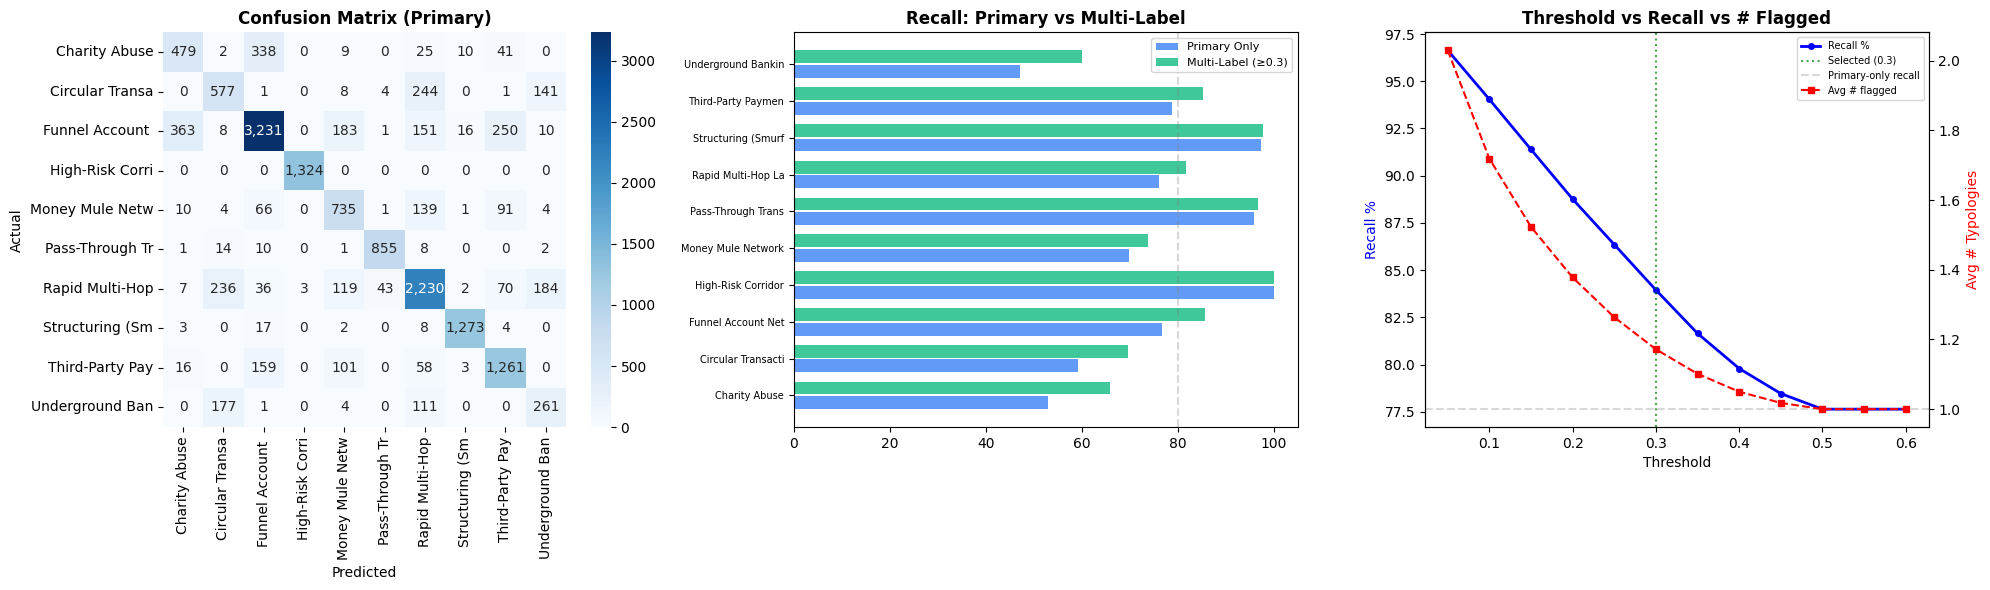

In [10]:
print("\n── Step 4: Phase 2 Evaluation (Multi-Label Threshold) ──")

# ═══ Multi-label threshold: flag all typologies above this probability ═══
TYPOLOGY_THRESHOLD = 0.30
print(f"  Typology threshold: {TYPOLOGY_THRESHOLD} (flag all typologies with prob >= {TYPOLOGY_THRESHOLD})")

# For each test transaction, get all typologies above threshold
y_pred_multi = []
y_pred_primary = []
y_true_labels = y_test_2.values

for i in range(len(y_proba_2)):
    probs = y_proba_2[i]
    primary = probs.argmax()
    y_pred_primary.append(primary)
    
    above_thresh = set(j for j in range(n_classes) if probs[j] >= TYPOLOGY_THRESHOLD)
    if not above_thresh:
        above_thresh = {primary}
    y_pred_multi.append(above_thresh)

# ═══ Recall: correct if TRUE typology is ANYWHERE in predicted set ═══
correct_multi = sum(1 for i in range(len(y_true_labels)) if y_true_labels[i] in y_pred_multi[i])
correct_primary = sum(1 for i in range(len(y_true_labels)) if y_true_labels[i] == y_pred_primary[i])

accuracy_primary = correct_primary / len(y_true_labels)
accuracy_multi = correct_multi / len(y_true_labels)

avg_flagged = np.mean([len(s) for s in y_pred_multi])
multi_label_pct = sum(1 for s in y_pred_multi if len(s) > 1) / len(y_pred_multi) * 100

print(f"\n  ┌─────────────────────────────────────────────────────────────┐")
print(f"  │  PRIMARY ONLY (highest prob):     {accuracy_primary:.4f} ({accuracy_primary*100:.1f}%)          │")
print(f"  │  MULTI-LABEL (threshold={TYPOLOGY_THRESHOLD}):  {accuracy_multi:.4f} ({accuracy_multi*100:.1f}%)          │")
print(f"  │  Improvement:                     +{(accuracy_multi-accuracy_primary)*100:.1f}%                     │")
print(f"  │  Avg typologies flagged/txn:       {avg_flagged:.2f}                      │")
print(f"  │  Transactions with 2+ typologies: {multi_label_pct:.1f}%                     │")
print(f"  └─────────────────────────────────────────────────────────────┘")

# ═══ Per-typology recall comparison ═══
print(f"\n  ── Per-Typology Recall: Primary vs Multi-Label ──")
print(f"  {'Typology':<40s} │ {'N':>6s} {'Primary':>8s} {'Multi':>8s} {'Gain':>7s} │ {'AvgConf':>8s} {'Avg#':>5s}")
print(f"  {'─'*95}")

for i, typ in idx_to_typ.items():
    mask = y_test_2 == i
    cnt = mask.sum()
    if cnt == 0: continue
    
    correct_p = sum(1 for j in range(len(y_true_labels)) if mask.iloc[j] and y_pred_primary[j] == i)
    recall_p = correct_p / cnt * 100
    
    correct_m = sum(1 for j in range(len(y_true_labels)) if mask.iloc[j] and i in y_pred_multi[j])
    recall_m = correct_m / cnt * 100
    
    gain = recall_m - recall_p
    avg_conf = np.mean([y_proba_2[j][i] for j in range(len(y_true_labels)) if mask.iloc[j]])
    avg_n = np.mean([len(y_pred_multi[j]) for j in range(len(y_true_labels)) if mask.iloc[j]])
    
    gain_str = f"+{gain:.1f}%" if gain > 0 else f"{gain:.1f}%"
    status = "✓" if recall_m > 80 else ("⚡" if recall_m > 50 else "⚠")
    print(f"  {typ:<40s} │ {cnt:>6,} {recall_p:>7.1f}% {recall_m:>7.1f}% {gain_str:>7s} │ {avg_conf:>7.3f} {avg_n:>5.2f} {status}")

# ═══ Threshold sensitivity analysis ═══
print(f"\n  ── Threshold Sensitivity ──")
print(f"  {'Threshold':>10s} │ {'Recall':>8s} {'Avg#':>6s} {'2+ Labels':>10s} │ {'vs Primary':>11s}")
print(f"  {'─'*60}")

for thresh in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    preds = []
    for j in range(len(y_proba_2)):
        above = set(k for k in range(n_classes) if y_proba_2[j][k] >= thresh)
        if not above: above = {y_proba_2[j].argmax()}
        preds.append(above)
    
    recall_t = sum(1 for j in range(len(y_true_labels)) if y_true_labels[j] in preds[j]) / len(y_true_labels) * 100
    avg_n_t = np.mean([len(s) for s in preds])
    multi_pct_t = sum(1 for s in preds if len(s) > 1) / len(preds) * 100
    
    marker = " ◄" if thresh == TYPOLOGY_THRESHOLD else ""
    print(f"  {thresh:>10.2f} │ {recall_t:>7.1f}% {avg_n_t:>5.2f} {multi_pct_t:>9.1f}% │ {recall_t - accuracy_primary*100:>+10.1f}%{marker}")

# ═══ Classification report (primary only — reference) ═══
print(f"\n  Classification Report (primary prediction):")
print(classification_report(y_test_2, y_pred_primary, target_names=typology_classes, digits=4))

# ═══ Plots ═══
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion matrix
cm = confusion_matrix(y_test_2, y_pred_primary)
short_names = [t[:15] for t in typology_classes]
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=axes[0],
            xticklabels=short_names, yticklabels=short_names)
axes[0].set_title("Confusion Matrix (Primary)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# 2. Per-typology recall comparison
typ_names_short = [idx_to_typ[i][:18] for i in range(n_classes)]
recall_primary_list = []
recall_multi_list = []
for i in range(n_classes):
    mask = y_test_2 == i; cnt = mask.sum()
    if cnt == 0: recall_primary_list.append(0); recall_multi_list.append(0); continue
    rp = sum(1 for j in range(len(y_true_labels)) if mask.iloc[j] and y_pred_primary[j] == i) / cnt * 100
    rm = sum(1 for j in range(len(y_true_labels)) if mask.iloc[j] and i in y_pred_multi[j]) / cnt * 100
    recall_primary_list.append(rp); recall_multi_list.append(rm)

x_pos = np.arange(n_classes)
axes[1].barh(x_pos - 0.2, recall_primary_list, 0.35, label="Primary Only", color="#3B82F6", alpha=0.8)
axes[1].barh(x_pos + 0.2, recall_multi_list, 0.35, label=f"Multi-Label (≥{TYPOLOGY_THRESHOLD})", color="#10B981", alpha=0.8)
axes[1].set_yticks(x_pos); axes[1].set_yticklabels(typ_names_short, fontsize=7)
axes[1].set_xlim(0, 105); axes[1].axvline(80, color="gray", linestyle="--", alpha=0.3)
axes[1].set_title("Recall: Primary vs Multi-Label", fontweight="bold")
axes[1].legend(fontsize=8)

# 3. Threshold sensitivity curve
thresholds_plot = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
recalls_plot = []
avg_n_plot = []
for thresh in thresholds_plot:
    preds = []
    for j in range(len(y_proba_2)):
        above = set(k for k in range(n_classes) if y_proba_2[j][k] >= thresh)
        if not above: above = {y_proba_2[j].argmax()}
        preds.append(above)
    recalls_plot.append(sum(1 for j in range(len(y_true_labels)) if y_true_labels[j] in preds[j]) / len(y_true_labels) * 100)
    avg_n_plot.append(np.mean([len(s) for s in preds]))

ax3a = axes[2]
ax3b = ax3a.twinx()
ax3a.plot(thresholds_plot, recalls_plot, "b-o", lw=2, markersize=4, label="Recall %")
ax3b.plot(thresholds_plot, avg_n_plot, "r--s", lw=1.5, markersize=4, label="Avg # flagged")
ax3a.axvline(TYPOLOGY_THRESHOLD, color="green", linestyle=":", alpha=0.7, label=f"Selected ({TYPOLOGY_THRESHOLD})")
ax3a.axhline(accuracy_primary * 100, color="gray", linestyle="--", alpha=0.3, label="Primary-only recall")
ax3a.set_xlabel("Threshold"); ax3a.set_ylabel("Recall %", color="blue"); ax3b.set_ylabel("Avg # Typologies", color="red")
ax3a.set_title("Threshold vs Recall vs # Flagged", fontweight="bold")
lines1, labels1 = ax3a.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3a.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "phase2_evaluation.png"), bbox_inches="tight")
plt.show()

## 11 — Build Production Output Tables


In [11]:
print("\n── Step 5: Build Production Output ──")

TYPOLOGY_THRESHOLD = 0.30

# Score full dataset Phase 1
fraud_risk_score = df_ml["_phase1_score"] * 100
predicted_aml = (df_ml["_phase1_score"] >= best_thresh).astype(int)

# Rule metrics
rule_cols = [c for c in df_ml.columns if c.startswith("rule_") and c not in {"rule_score", "rules_triggered", "rules_triggered_count"}]
rule_trigger_count = df_ml[rule_cols].sum(axis=1).astype(int) if rule_cols else pd.Series(0, index=df_ml.index)
rule_score_vals = pd.to_numeric(df_ml.get("rule_score", 0), errors="coerce").fillna(0)

# Column resolution
txn_id_col = next((c for c in ["transaction_id"] if c in df_ml.columns), None)
cif_col = next((c for c in ["customer_cif_id", "customer_account_number"] if c in df_ml.columns), None)
amt_col = next((c for c in ["transaction_amount"] if c in df_ml.columns), None)

# Alert source
has_rules = rule_trigger_count > 0; has_ml = predicted_aml == 1
alert_source = np.select(
    [has_rules & has_ml, has_rules & ~has_ml, ~has_rules & has_ml, ~has_rules & ~has_ml],
    ["Rule + ML Confirmed", "Rule Triggered", "ML Behavioural Alert", "Normal"], default="Normal")

# Phase 1 Output
phase1_output = pd.DataFrame({
    "transaction_id": df_ml[txn_id_col].values if txn_id_col else range(len(df_ml)),
    "customer_id": df_ml[cif_col].values if cif_col else "",
    "amount": df_ml[amt_col].values if amt_col else 0,
    "fraud_risk_score": np.round(fraud_risk_score.values, 1),
    "rule_trigger_count": rule_trigger_count.values,
    "alert_source": alert_source,
})


# ═══ Rule Explanations: Which specific rules triggered for each transaction ═══
print("  Generating rule-level explanations...")

# Rule display names for human-readable output
RULE_DISPLAY_NAMES = {
    "rule_structuring_pattern": "Sub-threshold cash structuring detected",
    "rule_negative_list_country": "FATF/sanctioned country involved",
    "rule_dormant_activation": "Dormant account suddenly reactivated",
    "rule_rapid_burst": "Rapid burst of transactions detected",
    "rule_large_cash_individual": "Large individual cash transaction",
    "rule_large_cash_business": "Large business cash transaction",
    "rule_pep_large_any": "PEP high-value transaction",
    "rule_off_hours_activity": "Suspicious off-hours activity",
    "rule_vpn_emulator_detected": "VPN/proxy/emulator detected",
    "rule_zero_balance_cycling": "Zero-balance drain cycling",
    "rule_tax_haven_remit": "Tax haven remittance",
    "rule_large_cr_dr_individual": "Large credit followed by debit",
    "rule_large_cr_dr_business": "Large business credit-debit pattern",
    "rule_multiple_parties_cash": "Multiple parties cash deposit",
    "rule_remit_then_cash_75pct": "Remittance then 75%+ cash withdrawal",
    "rule_credit_then_cash": "Credit then cash withdrawal pattern",
    "rule_high_freq_foreign": "High frequency foreign remittance",
    "rule_intra_high_freq": "High frequency intrabank transfers",
    "rule_series_credits_7d": "Series of credits in 7 days",
    "rule_series_debits_7d": "Series of debits in 7 days",
    "rule_new_wallet_high_value": "New wallet with high-value activity",
    "rule_short_lived_wallet": "Short-lived wallet high throughput",
    "rule_shell_company": "Shell company anomaly indicators",
    "rule_trust_large_cash": "Trust/society large cash handling",
    "rule_trust_foreign_remit": "Trust foreign remittance",
    "rule_offshore_entity": "Offshore entity transfer",
    "rule_age_amount_mismatch": "Age-amount mismatch (under 25)",
    "rule_low_income_large": "Low income high-value transaction",
    "rule_student_high_value": "Student high-value transaction",
    "rule_unemployed_large": "Retired/unemployed large transfer",
    "rule_pep_high_velocity": "PEP high velocity/circular pattern",
    "rule_minor_anomalous": "Minor anomalous profile activity",
    "rule_monthly_limit_exhaustion": "Monthly wallet limit exhaustion",
    "rule_device_hopping": "Multiple devices in short period",
    "rule_impossible_travel": "Impossible travel / location anomaly",
    "rule_auth_degrade_high_risk": "Auth degradation + high risk profile",
    "rule_ppi_small_kyc_load_breach": "Small KYC load limit breach",
    "rule_ppi_small_kyc_bal_breach": "Small KYC balance limit breach",
    "rule_ppi_negative_list_device": "Negative list device/IP detected",
    "rule_ppi_refund_abuse": "Merchant refund abuse pattern",
    "rule_ppi_multi_wallet_kyc": "Multiple wallets same PAN/Aadhaar",
    "rule_ppi_shared_ip_cluster": "Shared IP wallet cluster",
    "rule_ppi_w2w_layering": "Wallet-to-wallet layering pattern",
    "rule_ppi_high_risk_mcc": "High-risk MCC concentration >70%",
    "rule_ppi_cluster_alert": "Multi-signal wallet cluster alert",
    "rule_sole_prop_personal": "Self-employed using savings account",
    "rule_attempted_failed": "Failed/attempted transaction",
    "rule_unusual_type_spike": "Unusual transaction type spike",
    "rule_repeated_counterparty_7d": "Repeated counterparty in 7 days",
    "rule_round_amount_struct_7d": "Round amount structuring pattern",
    "rule_multi_channel_24h": "Multiple channels in 24 hours",
    "rule_rapid_load_transfer": "Rapid load then transfer (PPI)",
    "rule_new_indiv_cash_30pct": "New individual cash >30% income",
    "rule_dormant_75pct_drain": "Dormant account 75% drain in 7 days",
    "rule_fx_cash_large": "Foreign exchange cash large",
    "rule_cc_cash_1L": "Credit card cash advance ≥₹1L",
    "rule_tax_res_mismatch_xborder": "Tax residency mismatch cross-border",
    "rule_geo_mismatch_2000km": "Geo mismatch >2000km",
}



# Business explanations
explanations_map = {
    "Charity Abuse": "Suspicious donation patterns with high-value transfers to trust/society accounts",
    "Circular Transaction Loop": "Funds returning to originating account through circular transfer chain",
    "Funnel Account Network": "Multiple inflows from different sources converging into single account",
    "High-Risk Corridor Transfer": "Cross-border transfer to FATF high-risk jurisdiction",
    "Money Mule Network": "Account receiving and forwarding funds with rapid turnover pattern",
    "Pass-Through Transit Hub": "Account acting as transit point with immediate re-forwarding",
    "Rapid Multi-Hop Layering": "Sequential rapid transfers across multiple accounts to obscure trail",
    "Structuring (Smurfing)": "Transaction amounts structured below regulatory reporting thresholds",
    "Third-Party Payment Web": "Complex web of transfers through multiple third-party intermediaries",
    "Underground Banking (Hawala)": "Informal value transfer matching settlement patterns",
}




── Step 5: Build Production Output ──
  Generating rule-level explanations...


In [13]:
# ═══ Phase 2: Score predicted-AML with MULTI-LABEL threshold ═══
pred_aml_mask = predicted_aml == 1
X_for_p2 = df_ml.loc[pred_aml_mask, phase2_features].copy()
for c in X_for_p2.columns:
    X_for_p2[c] = pd.to_numeric(X_for_p2[c], errors="coerce").fillna(0)

# Initialize output columns
p2_primary_typology = ["None"] * len(df_ml)
p2_all_typologies = ["None"] * len(df_ml)
p2_primary_confidence = np.zeros(len(df_ml))
p2_num_matched = np.zeros(len(df_ml), dtype=int)
p2_priority = ["Low"] * len(df_ml)
p2_explanation = ["Transaction consistent with normal behaviour"] * len(df_ml)
p2_prob_data = {i: np.zeros(len(df_ml)) for i in range(n_classes)}



# Build rule explanation for each transaction
p2_rule_explanation = [""] * len(df_ml)
p2_rules_triggered_list = [""] * len(df_ml)
p2_rules_count = np.zeros(len(df_ml), dtype=int)

In [15]:
if rule_cols:
    print("  Generating rule explanations (vectorized)...")
    
    # Vectorized: get all rule flags as a boolean matrix
    rule_matrix = df_ml[rule_cols].fillna(0).astype(int)
    
    # Count rules per transaction (vectorized)
    p2_rules_count = rule_matrix.sum(axis=1).values
    
    # Build rule names and explanations only for rows with triggers
    triggered_mask = p2_rules_count > 0
    triggered_indices = np.where(triggered_mask)[0]
    
    print(f"    Processing {len(triggered_indices):,} transactions with ≥1 rule...")
    
    # Pre-build column name arrays for fast lookup
    rule_col_array = np.array(rule_cols)
    
    for pos in triggered_indices:
        row_flags = rule_matrix.iloc[pos].values == 1
        fired_rules = rule_col_array[row_flags]
        
        # Rule names list
        p2_rules_triggered_list[pos] = "; ".join(fired_rules)
        
        # Top 3 display names
        display_names = [RULE_DISPLAY_NAMES.get(r, r.replace("rule_", "").replace("_", " ").title()) for r in fired_rules[:3]]
        p2_rule_explanation[pos] = " | ".join(display_names)
        if len(fired_rules) > 3:
            p2_rule_explanation[pos] += f" | +{len(fired_rules)-3} more rules"
    
    # Set "No rules" for non-triggered
    for pos in np.where(~triggered_mask)[0]:
        p2_rule_explanation[pos] = "No compliance rules triggered"
    
    # Combine with typology explanation (vectorized using pandas)
    for pos in triggered_indices:
        if p2_explanation[pos] != "Transaction consistent with normal behaviour":
            p2_explanation[pos] = f"{p2_explanation[pos]} || Rules: {p2_rule_explanation[pos]}"
        else:
            p2_explanation[pos] = f"Rules: {p2_rule_explanation[pos]}"
    
    print(f"  Rule explanations generated for {triggered_mask.sum():,} transactions")

  Generating rule explanations (vectorized)...
    Processing 234,212 transactions with ≥1 rule...
  Rule explanations generated for 234,212 transactions


In [ ]:
# if rule_cols:
#     for pos in range(len(df_ml)):
#         triggered = []
#         for rc in rule_cols:
#             try:
#                 val = df_ml.iloc[pos][rc]
#                 if pd.notna(val) and val == 1:
#                     display_name = RULE_DISPLAY_NAMES.get(rc, rc.replace("rule_", "").replace("_", " ").title())
#                     triggered.append((rc, display_name))
#             except:
#                 pass
        
#         if triggered:
#             p2_rules_count[pos] = len(triggered)
#             p2_rules_triggered_list[pos] = "; ".join([rc for rc, _ in triggered])
            
#             # Top 3 most important rules as explanation
#             top_rules = triggered[:3]
#             p2_rule_explanation[pos] = " | ".join([desc for _, desc in top_rules])
#             if len(triggered) > 3:
#                 p2_rule_explanation[pos] += f" | +{len(triggered)-3} more rules"
#         else:
#             p2_rule_explanation[pos] = "No compliance rules triggered"
#             p2_rules_triggered_list[pos] = ""

#     # Combine rule explanation with typology explanation
#     for pos in range(len(df_ml)):
#         if p2_explanation[pos] != "Transaction consistent with normal behaviour" and p2_rule_explanation[pos] != "No compliance rules triggered":
#             p2_explanation[pos] = f"{p2_explanation[pos]} || Rules: {p2_rule_explanation[pos]}"
#         elif p2_rule_explanation[pos] != "No compliance rules triggered":
#             p2_explanation[pos] = f"Rules: {p2_rule_explanation[pos]}"

# print(f"  Rule explanations generated for {(p2_rules_count > 0).sum():,} transactions")




In [16]:
if len(X_for_p2) > 0:
    proba_full = model_p2.predict(X_for_p2)
    pred_positions = np.where(pred_aml_mask.values)[0]

    for j, pos in enumerate(pred_positions):
        probs = proba_full[j]
        primary_idx = probs.argmax()
        primary_name = idx_to_typ[primary_idx]
        primary_conf = float(probs.max())
        
        # All typologies above threshold
        matched = [(idx_to_typ[k], float(probs[k])) for k in range(n_classes) if probs[k] >= TYPOLOGY_THRESHOLD]
        if not matched:
            matched = [(primary_name, primary_conf)]
        matched.sort(key=lambda x: -x[1])
        
        # Primary = highest probability
        p2_primary_typology[pos] = matched[0][0]
        p2_primary_confidence[pos] = matched[0][1]
        
        # All matched typologies as semicolon-separated string with probabilities
        p2_all_typologies[pos] = "; ".join([f"{name} ({conf:.0%})" for name, conf in matched])
        p2_num_matched[pos] = len(matched)
        
        # Priority logic
        src = alert_source[pos]
        score = fraud_risk_score.iloc[pos]
        conf = matched[0][1]
        
        if src == "Rule + ML Confirmed" and conf >= 0.50:
            p2_priority[pos] = "Critical"
        elif score >= 70 or conf >= 0.60:
            p2_priority[pos] = "High"
        elif score >= 40 or conf >= 0.35 or src == "Rule Triggered":
            p2_priority[pos] = "Medium"
        else:
            p2_priority[pos] = "Low"
        
        # Explanation: combine all matched typologies
        explanations = [explanations_map.get(name, f"Behavioural anomaly (score={score:.0f})") for name, _ in matched]
        p2_explanation[pos] = explanations[0] if len(explanations) == 1 else f"{explanations[0]} | Also flagged: {'; '.join([name for name, _ in matched[1:]])}"
        
        # Store individual probabilities
        for k in range(n_classes):
            p2_prob_data[k][pos] = float(probs[k])



In [17]:
# Non-AML but rule-triggered → Medium priority
for pos in range(len(df_ml)):
    if not pred_aml_mask.iloc[pos] and alert_source[pos] == "Rule Triggered":
        p2_priority[pos] = "Medium"
        p2_explanation[pos] = f"Compliance rule triggered (score={int(rule_score_vals.iloc[pos])}) — routine monitoring"


# ═══ Build Phase 2 DataFrame ═══
phase2_output = pd.DataFrame({
    "transaction_id": phase1_output["transaction_id"].values,
    "customer_id": phase1_output["customer_id"].values,
    "predicted_typology": p2_primary_typology,
    "all_matched_typologies": p2_all_typologies,
    "num_typologies_matched": p2_num_matched,
    "typology_confidence": np.round(p2_primary_confidence, 4),
    "investigation_priority": p2_priority,
    "business_explanation": p2_explanation,
})

# Add individual probability columns
for i, t in idx_to_typ.items():
    col = f"prob_{t.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')}"
    phase2_output[col] = np.round(p2_prob_data[i], 4)

# ═══ Summary ═══
print(f"\n  Phase 1: {len(phase1_output):,} rows | Phase 2: {len(phase2_output):,} rows")
print(f"  Alert Sources: " + " | ".join([f"{s}: {(alert_source == s).sum():,}" for s in ["Rule + ML Confirmed", "Rule Triggered", "ML Behavioural Alert", "Normal"]]))

aml_p2 = phase2_output[phase2_output["predicted_typology"] != "None"]
print(f"\n  Multi-Label Statistics:")
print(f"    Transactions with AML prediction:  {len(aml_p2):,}")
print(f"    With 1 typology matched:           {(aml_p2['num_typologies_matched'] == 1).sum():,}")
print(f"    With 2 typologies matched:         {(aml_p2['num_typologies_matched'] == 2).sum():,}")
print(f"    With 3+ typologies matched:        {(aml_p2['num_typologies_matched'] >= 3).sum():,}")

print(f"\n  Predicted Typology Distribution (primary):")
print(f"  {'Typology':<40s} {'Count':>8s} {'%':>7s} {'Avg Matched':>12s}")
print(f"  {'─'*70}")
for typ in sorted(typology_classes):
    mask = phase2_output["predicted_typology"] == typ
    cnt = mask.sum()
    if cnt == 0: continue
    avg_m = phase2_output.loc[mask, "num_typologies_matched"].mean()
    print(f"  {typ:<40s} {cnt:>8,} {cnt / len(aml_p2) * 100:>6.1f}% {avg_m:>11.2f}")

print(f"\n  Investigation Priority Distribution:")
for pri in ["Critical", "High", "Medium", "Low"]:
    cnt = (phase2_output["investigation_priority"] == pri).sum()
    print(f"    {pri:<10s} {cnt:>10,} ({cnt / len(phase2_output) * 100:.1f}%)")

# ═══ Sample output ═══
print(f"\n  Sample Phase 2 Output (multi-label examples):")
multi_samples = phase2_output[phase2_output["num_typologies_matched"] >= 2]
if len(multi_samples) > 0:
    for _, r in multi_samples.sample(min(8, len(multi_samples)), random_state=42).iterrows():
        print(f"    {r['transaction_id']}: {r['all_matched_typologies']}")
        print(f"      Priority={r['investigation_priority']} | {r['business_explanation'][:80]}")
else:
    print(f"    No multi-label predictions at threshold {TYPOLOGY_THRESHOLD}")
    single_samples = phase2_output[phase2_output["predicted_typology"] != "None"].sample(min(5, len(aml_p2)), random_state=42)
    for _, r in single_samples.iterrows():
        print(f"    {r['transaction_id']}: {r['predicted_typology']} ({r['typology_confidence']:.2f})")


  Phase 1: 388,595 rows | Phase 2: 388,595 rows
  Alert Sources: Rule + ML Confirmed: 62,932 | Rule Triggered: 171,280 | ML Behavioural Alert: 28,223 | Normal: 126,160

  Multi-Label Statistics:
    Transactions with AML prediction:  91,155
    With 1 typology matched:           83,504
    With 2 typologies matched:         7,604
    With 3+ typologies matched:        47

  Predicted Typology Distribution (primary):
  Typology                                    Count       %  Avg Matched
  ──────────────────────────────────────────────────────────────────────
  Charity Abuse                               4,803    5.3%        1.21
  Circular Transaction Loop                   5,184    5.7%        1.09
  Funnel Account Network                     18,750   20.6%        1.15
  High-Risk Corridor Transfer                 6,705    7.4%        1.00
  Money Mule Network                          8,554    9.4%        1.06
  Pass-Through Transit Hub                    4,484    4.9%        1.00
 

In [ ]:
# # ═══ STEP 5: Build Output Tables with ELABORATE Business Explanations ═══
# print(f"\n── Step 5: Build Production Output ──")

# fraud_risk_score = df_ml["_phase1_score"]*100
# predicted_aml = (df_ml["_phase1_score"]>=best_thresh).astype(int)
# rule_cols_list = [c for c in df_ml.columns if c.startswith("rule_") and c not in {"rule_score","rules_triggered","rules_triggered_count"}]
# rule_trigger_count = df_ml[rule_cols_list].sum(axis=1).astype(int)
# rule_score_vals = pd.to_numeric(df_ml.get("rule_score",0),errors="coerce").fillna(0)

# txn_id_col=next((c for c in ["transaction_id"] if c in df.columns),None)
# cif_col=next((c for c in ["customer_cif_id","customer_account_number"] if c in df.columns),None)
# amt_col=next((c for c in ["transaction_amount"] if c in df.columns),None)
# channel_col=next((c for c in ["transaction_mode_channel_bank","transaction_mode_channel_ppi"] if c in df.columns),None)

# has_rules=rule_trigger_count>0; has_ml=predicted_aml==1
# alert_source=np.select([has_rules&has_ml,has_rules&~has_ml,~has_rules&has_ml,~has_rules&~has_ml],
#                         ["Rule + ML Confirmed","Rule Triggered","ML Behavioural Alert","Normal"],default="Normal")

# phase1_output = pd.DataFrame({
#     "transaction_id": df[txn_id_col].values if txn_id_col else range(len(df)),
#     "customer_id": df[cif_col].values if cif_col else "",
#     "amount": df[amt_col].values if amt_col else 0,
#     "channel": df[channel_col].values if channel_col else "",
#     "fraud_risk_score": np.round(fraud_risk_score.values,1),
#     "rule_trigger_count": rule_trigger_count.values,
#     "weighted_rule_score": rule_score_vals.values.astype(int),
#     "alert_source": alert_source,
# })

# # ═══ ELABORATE BUSINESS EXPLANATIONS ═══
# # Rule name → human-readable explanation mapping
# RULE_EXPLANATIONS = {
#     "rule_freq_2x_business": "Transaction frequency exceeds 2x the customer's historical baseline for business accounts",
#     "rule_freq_2x_individual": "Transaction frequency exceeds 2x the customer's historical baseline",
#     "rule_series_credits_7d": "Series of credit transactions in 7 days exceeding risk-adjusted threshold",
#     "rule_series_debits_7d": "Series of debit transactions in 7 days exceeding risk-adjusted threshold",
#     "rule_repeated_counterparty_7d": "Repeated transactions with the same counterparty within 7 days",
#     "rule_off_hours_activity": "Significant transaction activity during non-business hours (midnight to 5 AM)",
#     "rule_cross_entity_common": "Cross-entity transactions linked to a common person or beneficial owner",
#     "rule_integrated_cash_8_5_10L": "Cumulative cash transactions in 30 days approaching RBI reporting threshold (₹8.5L-10L)",
#     "rule_structuring_pattern": "Transaction amounts appear structured just below regulatory reporting thresholds (possible smurfing)",
#     "rule_multiple_parties_cash": "Cash deposits received from 3 or more different depositors in 7 days",
#     "rule_large_cr_dr_business": "Large credit followed by proportional debit within 30 days — possible layering",
#     "rule_credit_then_cash": "Credit received then immediately converted to cash withdrawal (50%+ of credit amount)",
#     "rule_dormant_activation": "Previously dormant account reactivated with high-value transaction",
#     "rule_negative_list_country": "Transaction involves counterparty in FATF high-risk or sanctioned jurisdiction",
#     "rule_tax_haven_remit": "Remittance to known tax haven jurisdiction (Switzerland, Cayman Islands, Panama, etc.)",
#     "rule_large_cash_business": "Large cash transaction by business entity exceeding risk-adjusted dynamic threshold",
#     "rule_large_cash_individual": "Large cash transaction by individual exceeding risk-adjusted dynamic threshold",
#     "rule_pep_large_any": "Politically Exposed Person (PEP) involved in large transaction exceeding risk threshold",
#     "rule_new_indiv_cash_30pct": "New account (<6 months) with cash transaction exceeding 30% of declared annual income",
#     "rule_dormant_75pct_drain": "Dormant account reactivated with immediate withdrawal of 75%+ of balance",
#     "rule_multi_channel_24h": "Transaction activity across 4+ different channels within 24 hours — possible account testing",
#     "rule_vpn_emulator_detected": "VPN, proxy, or device emulator detected — digital identity masking attempt",
#     "rule_device_hopping": "3+ different devices used within 2 hours — possible credential sharing or theft",
#     "rule_new_device_new_loc": "Transaction from both new device and new geographic location simultaneously",
#     "rule_shell_company": "Entity pattern: high transaction count but cumulative value <20% of balance — shell company indicator",
#     "rule_rapid_burst": "Burst of 3+ transactions within 1 hour — unusual velocity spike",
#     "rule_ppi_small_kyc_load_breach": "Prepaid wallet with minimum KYC received load exceeding ₹10,000 regulatory limit",
#     "rule_ppi_multi_wallet_kyc": "Same PAN/Aadhaar linked to 3+ prepaid wallets with high aggregate activity",
#     "rule_ppi_shared_ip_cluster": "10+ different wallets transacting from same IP address — coordinated network indicator",
#     "rule_ppi_high_risk_mcc": "Over 70% of wallet spend directed to high-risk merchant categories (gambling, crypto, gaming)",
#     "rule_ppi_w2w_layering": "Wallet-to-wallet transfers across 3+ hops within 24 hours — layering pattern",
#     "rule_impossible_travel": "Transaction location implies physically impossible travel speed between consecutive transactions",
#     "rule_ppi_negative_list_device": "Device, IP address, or UPI VPA found on institutional negative/watchlist",
# }

# TYPOLOGY_EXPLANATIONS = {
#     "Charity Abuse": "This transaction is part of a pattern where funds are being channeled through trust/society/NGO accounts. High-value donations or transfers to charitable entities that show suspicious patterns — such as immediate re-routing of donated funds, transfers to high-risk jurisdictions, or concentration of donations from related parties — indicate potential misuse of charitable vehicles for money laundering.",
#     "Circular Transaction Loop": "This transaction participates in a circular flow where funds leave an account and return to the same account (or a connected account) through a chain of intermediaries. The circular pattern is designed to create an appearance of legitimate business activity while the money effectively returns to its origin with a fabricated audit trail.",
#     "Funnel Account Network": "This transaction is part of a funnel pattern where multiple small deposits or transfers from different sources converge into a single recipient account. The many-to-one flow pattern suggests the receiving account is acting as a collection point, which is a common money laundering technique to aggregate illicit funds from distributed sources.",
#     "High-Risk Corridor Transfer": "This transaction involves a cross-border transfer through a high-risk financial corridor. The counterparty jurisdiction is classified as high-risk by FATF, and the transaction amount significantly exceeds the customer's typical cross-border activity. This combination of geographic risk and behavioral anomaly warrants enhanced due diligence.",
#     "Money Mule Network": "This account shows patterns consistent with a money mule — receiving funds and rapidly forwarding them to other accounts. The account holder's profile (age, income, occupation) does not match the volume and velocity of transactions, suggesting the account is being used by a third party to move illicit funds.",
#     "Pass-Through Transit Hub": "This account is acting as a transit point where received funds are immediately re-forwarded to other accounts with minimal holding time. The ratio of inflows to outflows approaches 1:1, and the account maintains near-zero end-of-day balance — classic indicators of a pass-through arrangement designed to obscure the source of funds.",
#     "Rapid Multi-Hop Layering": "This transaction is part of a rapid layering sequence where funds are moved through multiple accounts in quick succession. The speed and number of hops between accounts are designed to make it difficult for investigators to trace the original source of funds. Each hop typically involves different channels, amounts, or jurisdictions.",
#     "Structuring (Smurfing)": "This transaction is part of a structuring pattern where amounts are deliberately kept below regulatory reporting thresholds. Multiple transactions just under the CTR threshold (₹10 lakh for cash, ₹50,000 for certain electronic transfers) from the same customer or related parties indicate intentional avoidance of mandatory reporting requirements.",
#     "Third-Party Payment Web": "This transaction is part of a complex web of transfers involving multiple third-party intermediary accounts. The network of transactions creates a web-like pattern where funds are distributed and recombined through several unrelated accounts, making it difficult to identify the true beneficial owner or the ultimate purpose of the funds.",
# }

# def build_elaborate_explanation(row_pos, typology, confidence, source, score, triggered_rules_list):
#     parts = []
    
#     # Primary typology explanation
#     if typology and typology != "None" and typology in TYPOLOGY_EXPLANATIONS:
#         parts.append(f"TYPOLOGY DETECTED ({confidence*100:.0f}% confidence): {typology}")
#         parts.append(TYPOLOGY_EXPLANATIONS[typology])
    
#     # Rule breach explanations
#     if triggered_rules_list:
#         rule_explanations = []
#         for rule_name in triggered_rules_list[:5]:  # Top 5 rules
#             if rule_name in RULE_EXPLANATIONS:
#                 rule_explanations.append(f"  - {RULE_EXPLANATIONS[rule_name]}")
#             else:
#                 readable = rule_name.replace("rule_","").replace("_"," ").title()
#                 rule_explanations.append(f"  - {readable} threshold breached")
#         if rule_explanations:
#             parts.append(f"RULES BREACHED ({len(triggered_rules_list)} rules triggered, weighted score={int(score)}):")
#             parts.extend(rule_explanations)
    
#     # Alert source context
#     if source == "Rule + ML Confirmed":
#         parts.append("CONFIDENCE: HIGH — Both regulatory rules AND ML behavioural model independently flag this transaction.")
#     elif source == "ML Behavioural Alert":
#         parts.append("CONFIDENCE: MODERATE — ML model detects behavioural anomaly not captured by existing rules. Recommend manual review.")
#     elif source == "Rule Triggered":
#         parts.append("CONFIDENCE: STANDARD — Regulatory rule triggered. No ML behavioural anomaly detected. Routine compliance check.")
    
#     if not parts:
#         return "Transaction consistent with historical customer behaviour. No rules triggered, no ML anomaly detected."
    
#     return " | ".join(parts)

# # Build Phase 2 outputs
# pred_aml_mask = predicted_aml == 1
# X_for_p2 = df_ml.loc[pred_aml_mask, phase2_features].copy()
# for c in X_for_p2.columns: X_for_p2[c] = pd.to_numeric(X_for_p2[c], errors="coerce").fillna(0)

# p2_typology=["None"]*len(df_ml); p2_confidence=np.zeros(len(df_ml))
# p2_priority=["Low"]*len(df_ml); p2_explanation=[""]*len(df_ml)
# p2_prob_data={i:np.zeros(len(df_ml)) for i in range(n_classes)}

# if len(X_for_p2) > 0:
#     proba_full = model_p2.predict(X_for_p2)
#     pred_positions = np.where(pred_aml_mask.values)[0]
    
#     for j, pos in enumerate(pred_positions):
#         typ_idx=proba_full[j].argmax(); typ_name=idx_to_typ[typ_idx]; conf=float(proba_full[j].max())
#         src=alert_source[pos]; score=fraud_risk_score.iloc[pos]
        
#         p2_typology[pos]=typ_name; p2_confidence[pos]=conf
#         if src=="Rule + ML Confirmed" and conf>=0.50: p2_priority[pos]="Critical"
#         elif score>=70 or conf>=0.60: p2_priority[pos]="High"
#         elif score>=40 or conf>=0.35 or src=="Rule Triggered": p2_priority[pos]="Medium"
        
#         # Get triggered rules for this transaction
#         triggered = [r for r in rule_cols_list if r in df_ml.columns and df_ml.iloc[pos].get(r,0)==1]
#         p2_explanation[pos] = build_elaborate_explanation(pos, typ_name, conf, src, score, triggered)
#         for k in range(n_classes): p2_prob_data[k][pos]=float(proba_full[j,k])

# # Non-AML explanations
# for pos in range(len(df_ml)):
#     if not pred_aml_mask.iloc[pos]:
#         src=alert_source[pos]; score=rule_score_vals.iloc[pos]
#         if src=="Rule Triggered":
#             p2_priority[pos]="Medium"
#             triggered=[r for r in rule_cols_list if r in df_ml.columns and df_ml.iloc[pos].get(r,0)==1]
#             rule_expls = [RULE_EXPLANATIONS.get(r, r.replace("rule_","").replace("_"," ").title()) for r in triggered[:3]]
#             p2_explanation[pos] = f"ROUTINE MONITORING: {len(triggered)} compliance rules triggered (score={int(score)}). " + "; ".join(rule_expls)
#         else:
#             p2_explanation[pos] = "Transaction consistent with historical customer behaviour. No rules triggered, no ML anomaly detected."

# phase2_output = pd.DataFrame({
#     "transaction_id": phase1_output["transaction_id"].values,
#     "customer_id": phase1_output["customer_id"].values,
#     "predicted_typology": p2_typology,
#     "typology_confidence": np.round(p2_confidence,4),
#     "investigation_priority": p2_priority,
#     "business_explanation": p2_explanation,
# })
# for i,t in idx_to_typ.items():
#     col=f"prob_{t.lower().replace(' ','_').replace('-','_').replace('(','').replace(')','')}"
#     phase2_output[col]=np.round(p2_prob_data[i],4)

# # Sample output
# print(f"\n  Phase 1: {len(phase1_output):,} rows | Phase 2: {len(phase2_output):,} rows")
# print(f"  Alert Sources: " + " | ".join([f"{s}:{(alert_source==s).sum():,}" for s in ["Rule + ML Confirmed","Rule Triggered","ML Behavioural Alert","Normal"]]))

# samples=[]
# for st in ["Normal","Rule Triggered","ML Behavioural Alert","Rule + ML Confirmed"]:
#     n=2 if st!="Rule + ML Confirmed" else 4
#     m=phase1_output["alert_source"]==st
#     if m.sum()>0: samples.extend(phase1_output[m].sample(min(n,m.sum()),random_state=42).index.tolist())
# samples=samples[:10]

# print(f"\n  ── Sample Phase 1 Output ──")
# print(f"  {'TXN ID':<16s} {'Amount':>10s} {'FRS':>5s} {'Rules':>5s} {'WRS':>5s} {'Alert Source':<25s}")
# print(f"  {'─'*75}")
# for idx in samples:
#     r=phase1_output.iloc[idx]
#     print(f"  {str(r['transaction_id'])[:14]:<16s} {r['amount']:>10,.0f} {r['fraud_risk_score']:>5.0f} {int(r['rule_trigger_count']):>5d} {int(r['weighted_rule_score']):>5d} {str(r['alert_source']):<25s}")

# print(f"\n  ── Sample Phase 2 Output (with business explanation) ──")
# for idx in samples[:5]:
#     r2=phase2_output.iloc[idx]
#     print(f"\n  TXN: {r2['transaction_id']} | Priority: {r2['investigation_priority']} | Typology: {r2['predicted_typology']} ({r2['typology_confidence']:.2f})")
#     print(f"  Explanation: {str(r2['business_explanation'])[:200]}{'...' if len(str(r2['business_explanation']))>200 else ''}")


## 12 — Save Phase 2 Outputs


In [18]:
print("\n── Step 6: Save Outputs ──")

# Save outputs
phase1_output.to_parquet(os.path.join(OUTPUT_DIR, "phase1_aml_detection.parquet"), index=False)
phase2_output.to_parquet(os.path.join(OUTPUT_DIR, "phase2_typology_classification.parquet"), index=False)

combined = phase1_output.merge(phase2_output, on=["transaction_id","customer_id"], how="left")
combined.to_parquet(os.path.join(OUTPUT_DIR, "combined_aml_output.parquet"), index=False)
combined.to_csv(os.path.join(OUTPUT_DIR, "combined_aml_output.csv"), index=False)

# Save model
model_p2.save_model(os.path.join(OUTPUT_DIR, "phase2_typology_model.txt"))

# Save metadata
# Save model parameters for Excel summary
import json as _json
model_params = {
    
    "phase2": {
        "best_config": best_p2,
        "config_details": p2_results[best_p2]["config"],
        "accuracy": accuracy,
        "macro_f1": float(f1_score(y_test_2,y_pred_2,average="macro")),
        "weighted_f1": float(f1_score(y_test_2,y_pred_2,average="weighted")),
        "best_iteration": int(p2_results[best_p2]["rounds"]),
        "n_classes": n_classes,
        "classes": typology_classes,
        "n_features": len(phase2_features),
        "n_train": len(X_train_2),
        "n_test": len(X_test_2),
        "all_configs": {k:{"acc":v["acc"],"mf1":v["mf1"],"wf1":v["wf1"],"rounds":v["rounds"]} for k,v in p2_results.items()},
    }
}
with open(os.path.join(OUTPUT_DIR,"model_parameters_full.json"),"w") as f:
    _json.dump(model_params,f,indent=2,default=str)

typ_mapping={"typ_to_idx":typ_to_idx,"idx_to_typ":{str(k):v for k,v in idx_to_typ.items()}}
with open(os.path.join(OUTPUT_DIR,"typology_mapping.json"),"w") as f:
    _json.dump(typ_mapping,f,indent=2)

print(f"\n  Saved files:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    fp=os.path.join(OUTPUT_DIR,fn)
    if not os.path.isdir(fp):
        print(f"    {fn:<50s} {os.path.getsize(fp)/(1024*1024):>8.2f} MB")

print(f"\n{'='*90}")
print("PIPELINE COMPLETE")
print(f"{'='*90}")
#print(f"  Phase 1: AUC={results[best_strategy]['auc']:.4f} | F1={results[best_strategy]['f1']:.4f} | Recall={results[best_strategy]['recall']:.4f}")
print(f"  Phase 2: Accuracy={accuracy:.4f} | Config={best_p2}")
#print(f"  Rules: {len(selected_rules)} kept / {len(removed_rules)} removed (from 126)")
print(f"  Total features: {len(features_final)}")
print(f"  Model params saved to: model_parameters_full.json")


── Step 6: Save Outputs ──

  Saved files:
    combined_aml_output.csv                               72.82 MB
    combined_aml_output.parquet                           12.82 MB
    model_parameters_full.json                             0.00 MB
    phase1_aml_detection.parquet                           9.85 MB
    phase2_evaluation.png                                  0.13 MB
    phase2_typology_classification.parquet                 9.80 MB
    phase2_typology_model.txt                             56.45 MB
    typology_mapping.json                                  0.00 MB

PIPELINE COMPLETE
  Phase 2: Accuracy=0.7744 | Config=Deep+Reg
  Total features: 232
  Model params saved to: model_parameters_full.json


## Appendix — Code to Add to Phase 1 Notebook
Add this at the end of your Phase 1 notebook to save all required artifacts for Phase 2.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ADD THIS TO THE END OF YOUR PHASE 1 (04__aml_ml_preparation) NOTEBOOK
# It saves everything Phase 2 needs to run independently
# ═══════════════════════════════════════════════════════════════

# Already saved by existing code:
#   final_model.save_model(os.path.join(OUTPUT_DIR, "final_lgb_model.txt"))
#   X_train.to_parquet(os.path.join(OUTPUT_DIR, "X_train.parquet"))
#   X_test.to_parquet(os.path.join(OUTPUT_DIR, "X_test.parquet"))
#   y_train.to_frame().to_parquet(os.path.join(OUTPUT_DIR, "y_train.parquet"))
#   y_test.to_frame().to_parquet(os.path.join(OUTPUT_DIR, "y_test.parquet"))
#   model_metadata.json (contains features, threshold, strategy)

# ADDITIONAL: Save the full feature-engineered dataset path
# The Phase 2 notebook needs access to the feature file to get typology labels
# Make sure stg_transactions_features_V2.parquet is in the parent of OUTPUT_DIR

# print("Phase 1 artifacts saved. Phase 2 notebook can now run independently.")
# print(f"  Required files in {OUTPUT_DIR}:")
# print(f"    final_lgb_model.txt")
# print(f"    model_metadata.json")
# print(f"    X_train.parquet, X_test.parquet")
# print(f"    y_train.parquet, y_test.parquet")
# print(f"  Required file in parent directory:")
# print(f"    stg_transactions_features_V2.parquet")
